In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [4]:
url='https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv'

df = pd.read_csv(url, usecols=[1])
data = df.values.astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [5]:
SEQ_LENGTH = 10
X = np.array([data_scaled[i:i+SEQ_LENGTH] for i in range(len(data_scaled) -
SEQ_LENGTH)])
y = np.array([data_scaled[i + SEQ_LENGTH] for i in range(len(data_scaled) -
SEQ_LENGTH)])
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [6]:
import torch
from torch.utils.data import TensorDataset, DataLoader
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=1)

In [7]:
import torch.nn as nn
class BiRNN(nn.Module):
  def __init__(self, input_size=1, hidden_size=64, num_layers=1):
    super(BiRNN, self).__init__()
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True,bidirectional=True)
    self.fc = nn.Linear(hidden_size * 2, 1)
  def forward(self, x):
    out, _ = self.rnn(x)
    return self.fc(out[:, -1, :])
class FeedforwardNN(nn.Module):
  def __init__(self, input_size):
    super(FeedforwardNN, self).__init__()

    self.fc1 = nn.Linear(input_size, 64)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(64, 1)
  def forward(self, x):
    x = x.view(x.size(0), -1)
    return self.fc2(self.relu(self.fc1(x)))

In [9]:
def train_model(model, loader, epochs=100):
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
  model.train()
  for epoch in range(epochs):
    loss_epoch = 0
    for seqs, targets in loader:
      optimizer.zero_grad()
      outputs = model(seqs)
      loss = criterion(outputs, targets)
      loss.backward()
      optimizer.step()
      loss_epoch += loss.item()
    if (epoch + 1) % 20 == 0:
      print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_epoch / len(loader):.5f}")
def evaluate_model(model, X):
  model.eval()
  with torch.no_grad():
    return model(X).numpy()

In [10]:
birnn = BiRNN()
train_model(birnn, train_loader)
ffnn = FeedforwardNN(input_size=SEQ_LENGTH)
train_model(ffnn, train_loader)
pred_birnn = evaluate_model(birnn, X_test_tensor)
pred_ffnn = evaluate_model(ffnn, X_test_tensor)

Epoch 20/100, Loss: 0.00218
Epoch 40/100, Loss: 0.00254
Epoch 60/100, Loss: 0.00255
Epoch 80/100, Loss: 0.00197
Epoch 100/100, Loss: 0.00194
Epoch 20/100, Loss: 0.00368
Epoch 40/100, Loss: 0.00217
Epoch 60/100, Loss: 0.00178
Epoch 80/100, Loss: 0.00164
Epoch 100/100, Loss: 0.00191


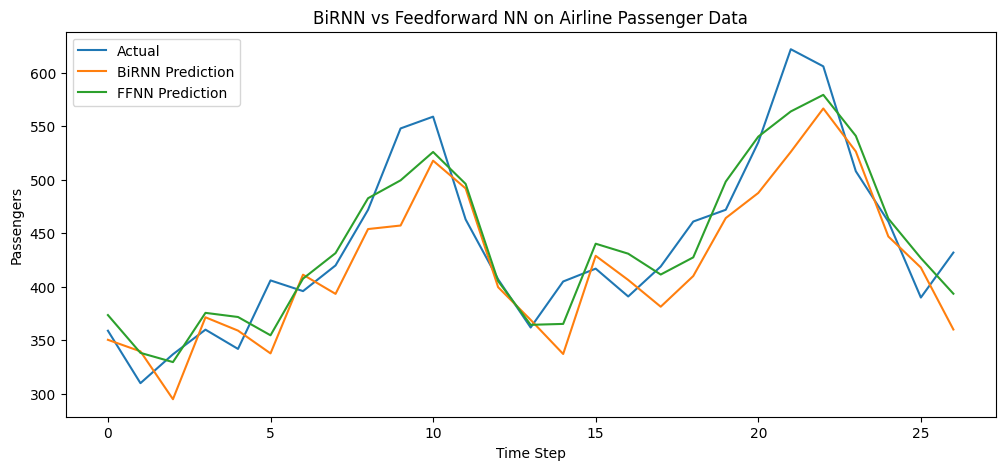

BiRNN MSE: 1793.552
FFNN MSE: 866.795


In [11]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
pred_birnn_inv = scaler.inverse_transform(pred_birnn)
pred_ffnn_inv = scaler.inverse_transform(pred_ffnn)
y_test_inv = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='Actual')
plt.plot(pred_birnn_inv, label='BiRNN Prediction')
plt.plot(pred_ffnn_inv, label='FFNN Prediction')
plt.legend()
plt.title('BiRNN vs Feedforward NN on Airline Passenger Data')
plt.xlabel('Time Step')
plt.ylabel('Passengers')
plt.show()
mse_birnn = mean_squared_error(y_test_inv, pred_birnn_inv)
mse_ffnn = mean_squared_error(y_test_inv, pred_ffnn_inv)
print(f"BiRNN MSE: {mse_birnn:.3f}")
print(f"FFNN MSE: {mse_ffnn:.3f}")